# Visual comparison of SPCA and regular PCA

The purpose of this notebook is to better understand how Supervised PCA varies from regular PCA by visual comparison on the same dataset (data/parkinsons.data). 

We will use SPCA via manifold optimization with the main hyperparameter lambda set to 0.01. More about this method and this parameter choice is available in it's dedicated notebook (experiments/spca.ipynb)

In [10]:
from models import SupervisedPCA, spca_normalized_loss
from utils import load_parkinsons_data, normalize_to_minus1_1
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Prepare data
X, y, feature_names = load_parkinsons_data(device)

# Center features
X = X - X.mean(dim=0)
y = y - y.mean(dim=0)

# Normalize features
X = normalize_to_minus1_1(X)
y = normalize_to_minus1_1(y)

print(X.shape)
print(y.shape)

torch.Size([1000, 19])
torch.Size([1000, 1])


## Prepare both models

In [4]:
# Compute the unsupervised PCA model
U, S, Vt = torch.linalg.svd(X)
L_pca = Vt[:2].T

In [5]:
# Train the Supervised PCA model
model = SupervisedPCA(input_dim=X.shape[1], output_dim=2)
model.train(X, y, lam=0.01, steps=200)

Step 0: loss = 332.4944
Step 10: loss = 239.1380
Step 20: loss = 236.4748
Step 30: loss = 234.7331
Step 40: loss = 232.0722
Step 50: loss = 230.9810
Step 60: loss = 230.6495
Step 70: loss = 230.4262
Step 80: loss = 230.2139
Step 90: loss = 230.0437
Step 100: loss = 229.9047
Step 110: loss = 229.7717
Step 120: loss = 229.6475
Step 130: loss = 229.5535
Step 140: loss = 229.4649
Step 150: loss = 229.3789
Step 160: loss = 229.2997
Step 170: loss = 229.2382
Step 180: loss = 229.1600
Step 190: loss = 229.1015


## Results comparison

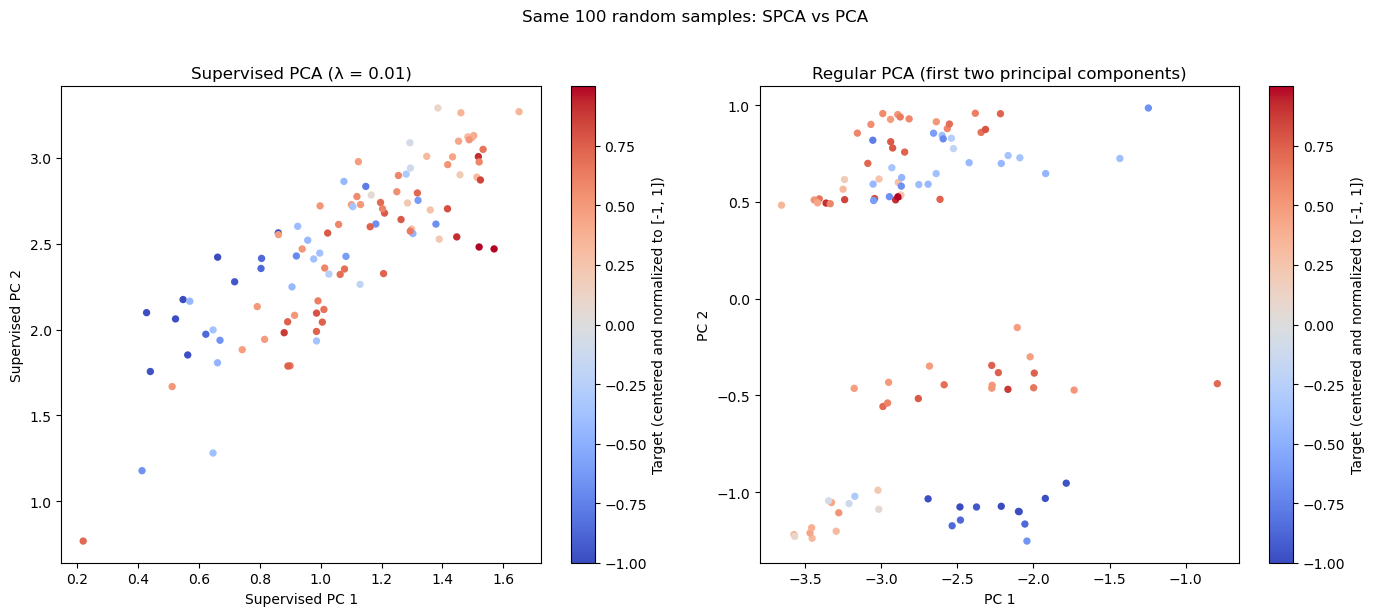

In [13]:
torch.manual_seed(0)
idx = torch.randperm(X.shape[0], device=X.device)[:100]
X_s = X[idx]
y_s = y[idx].squeeze(-1)

L_spca = model.L.detach()
proj_spca = X_s @ L_spca
proj_pca = X_s @ L_pca

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

sc0 = axes[0].scatter(
    proj_spca[:, 0].cpu().numpy(),
    proj_spca[:, 1].cpu().numpy(),
    c=y_s.cpu().numpy(),
    cmap="coolwarm",
    s=28,
    edgecolors="none",
)
axes[0].set_xlabel("Supervised PC 1")
axes[0].set_ylabel("Supervised PC 2")
axes[0].set_title("Supervised PCA (λ = 0.01)")
fig.colorbar(sc0, ax=axes[0], label="Target (centered and normalized to [-1, 1])")

sc1 = axes[1].scatter(
    proj_pca[:, 0].cpu().numpy(),
    proj_pca[:, 1].cpu().numpy(),
    c=y_s.cpu().numpy(),
    cmap="coolwarm",
    s=28,
    edgecolors="none",
)
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].set_title("Regular PCA (first two principal components)")
fig.colorbar(sc1, ax=axes[1], label="Target (centered and normalized to [-1, 1])")

fig.suptitle("Same 100 random samples: SPCA vs PCA", y=1.02)
plt.tight_layout()
plt.show()

Supervised PCA is optimized for linear regression, which is why the instances grow in their target value as you move from the bottom left to top right. Regular PCA only cares about the directions of maximum variance, but still does a good job separating instances with a high target variable from those with a low target variable. This result would not be very useful for linear regression (for which Supervised PCA is optimized), but could work better with more advanced methods like neural networks.

In [11]:
A = model.L.detach().cpu().numpy()
P = L_pca.detach().cpu().numpy()
k, names = 5, list(feature_names)

for j in range(2):
    oa = np.argsort(-np.abs(A[:, j]))[:k]
    op = np.argsort(-np.abs(P[:, j]))[:k]
    display(Markdown(f"#### Component {j + 1}"))
    display(
        pd.DataFrame(
            {
                ("Supervised PCA", "Feature"): [names[i] for i in oa],
                ("Supervised PCA", "Loading"): [f"{A[i, j]:+.3f}" for i in oa],
                ("Regular PCA", "Feature"): [names[i] for i in op],
                ("Regular PCA", "Loading"): [f"{P[i, j]:+.3f}" for i in op],
            },
            index=range(1, k + 1),
        ).rename_axis("Rank")
    )


#### Component 1

Supervised PCA           Regular PCA        
            Feature Loading       Feature Loading
Rank                                             
1       Jitter:PPQ5  -0.433           sex  +0.355
2       Jitter(Abs)  -0.425   Shimmer:DDA  +0.292
3           Shimmer  -0.314  Shimmer:APQ3  +0.292
4       Shimmer(dB)  -0.293  Shimmer:APQ5  +0.283
5      Shimmer:APQ5  +0.280       Shimmer  +0.272

#### Component 2

Supervised PCA         Regular PCA        
            Feature Loading     Feature Loading
Rank                                           
1      Shimmer:APQ5  -0.430         age  +0.955
2        Jitter:RAP  -0.385         DFA  -0.182
3        Jitter:DDP  -0.385        RPDE  +0.172
4               sex  -0.323         HNR  -0.090
5     Shimmer:APQ11  -0.307         PPE  +0.066

A side by side comparison of the principle components as weighted sums of the original features (loadings) shows that in the end, PCA and Supervised PCA use very different principal components.